In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver #this will help in saving the code in RAM

In [2]:
load_dotenv()

True

In [3]:
LLM = ChatGroq(model = "openai/gpt-oss-120b", temperature=0.7)

In [4]:
class jokestate(TypedDict):
    
    joke: str
    topic: str
    explanation: str

In [5]:
def generate_joke(state: jokestate):
    prompt = f"generate a joke form the topic - {state['topic']}"
    
    response = LLM.invoke(prompt)
    
    return {"joke": response}

In [6]:
def generate_exp(state: jokestate):
    prompt = f"Generate a proper samll exp of the joke - {state['joke']}"
    
    response = LLM.invoke(prompt)
    
    return {"explanation": response}

In [11]:
graph = StateGraph(jokestate)

# node
graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_exp", generate_exp)

# edge
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_exp")
graph.add_edge("generate_exp", END)

checkpointer = InMemorySaver()  # object for the inmemory saver

workflow_with_persistence = graph.compile(checkpointer=checkpointer)

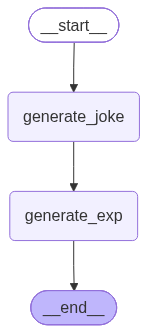

In [12]:
workflow_with_persistence

In [38]:
# creating the thread
config1 = {"configurable": {"thread_id": "1"}}
workflow_with_persistence.invoke({"topic": "pizza"}, config=config1)

{'joke': AIMessage(content='Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally stop being a *slice* of the unemployment pie! 🍕😄', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - pizza". Likely they want a joke about pizza. Provide a humorous joke. Ensure compliance. It\'s fine.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 79, 'total_tokens': 159, 'completion_time': 0.167747329, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003191593, 'prompt_tokens_details': None, 'queue_time': 0.281944635, 'total_time': 0.170938922}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f991c-6552-7b51-83a0-9a02d26bd43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tokens': 80, 'total_token

In [39]:
# suppose yu came after a very long time and want to see your project state where yu left
# you will type
workflow_with_persistence.get_state(config1)

StateSnapshot(values={'joke': AIMessage(content='Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally stop being a *slice* of the unemployment pie! 🍕😄', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - pizza". Likely they want a joke about pizza. Provide a humorous joke. Ensure compliance. It\'s fine.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 79, 'total_tokens': 159, 'completion_time': 0.167747329, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003191593, 'prompt_tokens_details': None, 'queue_time': 0.281944635, 'total_time': 0.170938922}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f991c-6552-7b51-83a0-9a02d26bd43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_toke

In [40]:
# if yu wanna see intermediate values you will type
list(workflow_with_persistence.get_state_history(config1))

[StateSnapshot(values={'joke': AIMessage(content='Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally stop being a *slice* of the unemployment pie! 🍕😄', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - pizza". Likely they want a joke about pizza. Provide a humorous joke. Ensure compliance. It\'s fine.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 79, 'total_tokens': 159, 'completion_time': 0.167747329, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003191593, 'prompt_tokens_details': None, 'queue_time': 0.281944635, 'total_time': 0.170938922}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f991c-6552-7b51-83a0-9a02d26bd43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tok

In [37]:
# lets create another thread
config2 = {"configurable": {"thread_id": "2"}}
workflow_with_persistence.invoke({"topic":"pasta"}, config=config2)

{'joke': AIMessage(content='Why did the spaghetti get a promotion?  \n\nBecause it always knew how to *work its noodles* and never got tangled up in office drama! 🍝😄', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user asks: "generate a joke form the topic - pasta". Likely they mean "from the topic - pasta". So we need to produce a joke about pasta. Ensure it\'s appropriate. Provide maybe a one-liner or a short joke. Also could be a pun. Let\'s respond.'}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 79, 'total_tokens': 189, 'completion_time': 0.229881373, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.002979456, 'prompt_tokens_details': None, 'queue_time': 0.281196092, 'total_time': 0.232860829}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f991c-2961-7782

In [33]:
workflow_with_persistence.get_state(config2)

StateSnapshot(values={'joke': AIMessage(content='Why did the spaghetti get a promotion?\n\nBecause it always knew how to *pasta* the test! 🍝', additional_kwargs={'reasoning_content': 'The user wants a joke from the topic "pasta". So produce a joke. Should be appropriate. Provide a joke.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 79, 'total_tokens': 137, 'completion_time': 0.12018202, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.003424721, 'prompt_tokens_details': None, 'queue_time': 0.284253335, 'total_time': 0.123606741}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_acbbc9c4c3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9919-41b3-7d80-86d9-e49cf053c518-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tokens': 58, 'total_tokens': 137, 'output_token_details': {'reasoning': 26}}), 'topic': 'pasta', 

In [34]:
list(workflow_with_persistence.get_state_history(config2))

[StateSnapshot(values={'joke': AIMessage(content='Why did the spaghetti get a promotion?\n\nBecause it always knew how to *pasta* the test! 🍝', additional_kwargs={'reasoning_content': 'The user wants a joke from the topic "pasta". So produce a joke. Should be appropriate. Provide a joke.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 79, 'total_tokens': 137, 'completion_time': 0.12018202, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.003424721, 'prompt_tokens_details': None, 'queue_time': 0.284253335, 'total_time': 0.123606741}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_acbbc9c4c3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9919-41b3-7d80-86d9-e49cf053c518-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tokens': 58, 'total_tokens': 137, 'output_token_details': {'reasoning': 26}}), 'topic': 'pasta',

<h1> Time travel using Langgraph</h1>

In [41]:
workflow_with_persistence.get_state({"configurable": {"thread_id": "1", "checkpoint_id ": "1f1881e7-e177-66d2-bfff-529cf896af61"}})

StateSnapshot(values={'joke': AIMessage(content='Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally stop being a *slice* of the unemployment pie! 🍕😄', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - pizza". Likely they want a joke about pizza. Provide a humorous joke. Ensure compliance. It\'s fine.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 79, 'total_tokens': 159, 'completion_time': 0.167747329, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003191593, 'prompt_tokens_details': None, 'queue_time': 0.281944635, 'total_time': 0.170938922}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f991c-6552-7b51-83a0-9a02d26bd43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_toke

In [42]:
workflow_with_persistence.invoke(None,{"configurable": {"thread_id": "1", "checkpoint_id ": "1f1881e7-e177-66d2-bfff-529cf896af61"}})

{'joke': AIMessage(content='Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally stop being a *slice* of the unemployment pie! 🍕😄', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - pizza". Likely they want a joke about pizza. Provide a humorous joke. Ensure compliance. It\'s fine.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 79, 'total_tokens': 159, 'completion_time': 0.167747329, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003191593, 'prompt_tokens_details': None, 'queue_time': 0.281944635, 'total_time': 0.170938922}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f991c-6552-7b51-83a0-9a02d26bd43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tokens': 80, 'total_token

In [43]:
list(workflow_with_persistence.get_state_history(config1))

[StateSnapshot(values={'joke': AIMessage(content='Why did the pizza apply for a job?\n\nBecause it wanted to earn some *dough* and finally stop being a *slice* of the unemployment pie! 🍕😄', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - pizza". Likely they want a joke about pizza. Provide a humorous joke. Ensure compliance. It\'s fine.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 79, 'total_tokens': 159, 'completion_time': 0.167747329, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003191593, 'prompt_tokens_details': None, 'queue_time': 0.281944635, 'total_time': 0.170938922}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f991c-6552-7b51-83a0-9a02d26bd43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tok

<h1>Updating the state</h1>

In [47]:
workflow_with_persistence.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1881d5-da17-63a1-8000-06f9b1679bbf", "checkpoint_ns": ""}}, {"topic": "samosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f188399-2495-6339-8001-a8d3b1928764'}}

In [52]:
workflow_with_persistence.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f188399-2495-6339-8001-a8d3b1928764"}})

{'joke': AIMessage(content='Why did the samosa apply for a job?  \n\nBecause it heard the position was *crisp* and it wanted to *fill* its résumé!', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - samosa". Probably they meant "from". Provide a joke about samosa. Should be appropriate. No disallowed content. Provide a joke.'}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 80, 'total_tokens': 162, 'completion_time': 0.171427247, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.014726623, 'prompt_tokens_details': None, 'queue_time': 0.287221293, 'total_time': 0.18615387}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f99cc-5679-73e1-88db-bbc31bf18b10-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_tokens': 82, 'tota

In [ ]:
list(workflow_with_persistence.get_state_history(config1))

[StateSnapshot(values={'joke': AIMessage(content='Why did the samosa apply for a job?  \n\nBecause it heard the position was *crisp* and it wanted to *fill* its résumé!', additional_kwargs={'reasoning_content': 'The user asks: "generate a joke form the topic - samosa". Probably they meant "from". Provide a joke about samosa. Should be appropriate. No disallowed content. Provide a joke.'}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 80, 'total_tokens': 162, 'completion_time': 0.171427247, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.014726623, 'prompt_tokens_details': None, 'queue_time': 0.287221293, 'total_time': 0.18615387}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f99cc-5679-73e1-88db-bbc31bf18b10-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'out

: 